In [3]:
import pandas as pd 
import seaborn as sns
df = pd.read_csv('D:\\Scaler case study data\\walmart_data.txt')
df


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


##Detect Null values & Outliers (using boxplot, “describe” method by checking the difference between mean and median, isnull etc.)


In [3]:
print(df.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


<Axes: xlabel='Marital_Status', ylabel='Purchase'>

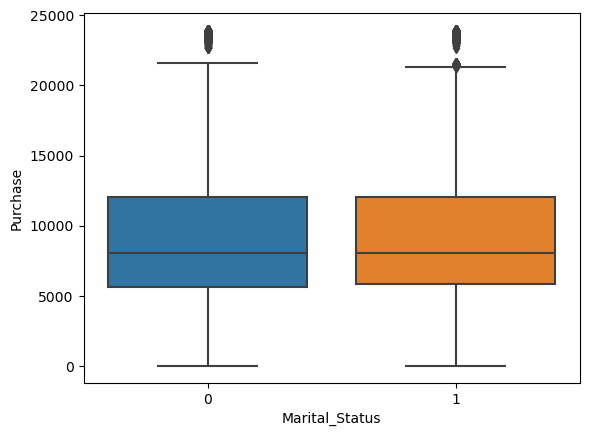

In [11]:
sns.boxplot(data=df, x='Marital_Status', y='Purchase', hue=None)

<Axes: xlabel='Gender', ylabel='Purchase'>

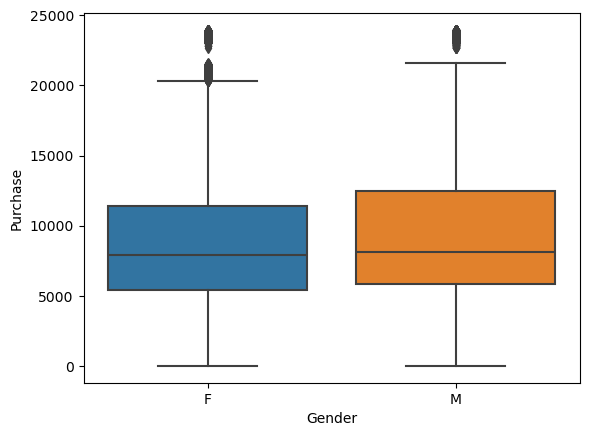

In [4]:
sns.boxplot(data=df, x='Gender', y='Purchase', hue=None)


##EDA

##Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, 
##calculate the average, and conclude the results.

In [5]:
amount = df.groupby('Gender')['Purchase'].mean()
amount

Gender
F    8734.565765
M    9437.526040
Name: Purchase, dtype: float64

In [6]:
amount = df.groupby('Gender')['Purchase'].count()
amount

Gender
F    135809
M    414259
Name: Purchase, dtype: int64

##Inference after computing the average female and male expenses.

In [ ]:
##ON average male customers are more spent compared to female 

In [ ]:
## Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.

In [2]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Gender'] == 'F']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average Female Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all 100 million customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average Female Spending: 8734.57
We are 95% confident that the true population average spending 
for all 100 million customers lies between 8709.21 and 8759.92


In [ ]:
## This insight from this calculatin predictive certainty instead of gusiing a single exact number for 100 million people 
##This sample gives highly accurate estimate of total female purchases 

In [19]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

Male_sample = df[df['Gender'] == 'M']['Purchase']

n = len(Male_sample)
sample_mean = Male_sample.mean()
sample_sem = stats.sem(Male_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average Male Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all 100 million customers lies between ${lower_bound:.2f} and ${upper_bound:.2f}")

Sample Average Male Spending: 9437.53
We are 95% confident that the true population average spending 
for all 100 million customers lies between $9422.02 and $9453.03


In [ ]:
##Are women spending more money per transaction than men? Why or Why not?

##No, women are not spending more money per transaction than men.

##The average purchase amount for male customers is higher than that of female customers. 
##Based on the analysis, the average spending per transaction for male customers is approximately ₹9,438, whereas for female customers it is approximately ₹8,735.

##This indicates that male customers spend more money per transaction on average. 
##The sampling distributions generated using the Central Limit Theorem were centered around these population means, 
##confirming that the observed difference is consistent across repeated samples and is not due to random chance.

## CLT
Use the central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.

In [5]:
female_purchase = df[df['Gender']=='F']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)


1000

In [6]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 8730.254018
sampling_std: 153.90065749734043


In [7]:
population_mean_female = df[df['Gender']=='F']['Purchase'].mean()
population_mean_female

8734.565765155476

In [8]:
lower = sampling_mean - 1.96*sampling_std
lower

8428.608729305211

In [9]:
upper = sampling_mean + 1.96*sampling_std
upper

9031.899306694788

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of Female Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

NameError: name 'sample_means' is not defined

<Figure size 1000x500 with 0 Axes>

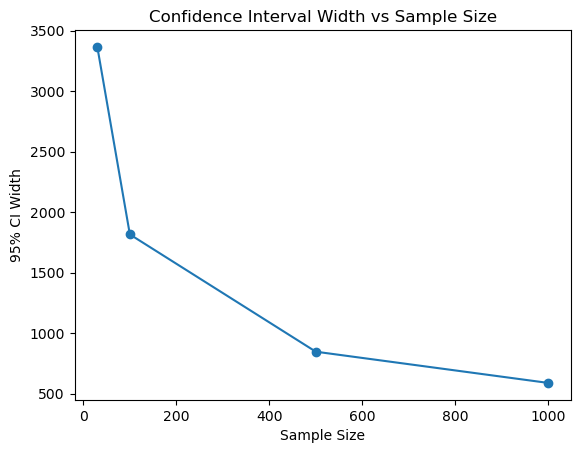

In [70]:
widths = []

for n in [30,100,500,1000]:

    means = []

    for _ in range(1000):
        sample = female_purchase.sample(n=n, replace=True)
        means.append(sample.mean())

    mean_sampling = np.mean(means)
    std_sampling = np.std(means)

    lower = mean_sampling - 1.96 * std_sampling
    upper = mean_sampling + 1.96 * std_sampling

    widths.append(upper - lower)

plt.plot([30,100,500,1000], widths, marker='o')
plt.xlabel("Sample Size")
plt.ylabel("95% CI Width")
plt.title("Confidence Interval Width vs Sample Size")
plt.show()

In [ ]:
## Conclusion from above graph-> As the smaple size increses variability decreses 

In [86]:
male_purchase = df[df['Gender']=='M']['Purchase']

sample_means = []

for i in range(1000):
    sample = male_purchase.sample(n=100, replace= True)
    sample_means.append(sample.mean())

len(sample_means)


1000

In [87]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 9445.15955
sampling_std: 509.01904081939557


In [94]:
population_mean_male = df[df['Gender']=='M']['Purchase'].mean()
population_mean_male

9437.526040472265

In [89]:
lower = sampling_mean - 1.96*sampling_std
lower

8447.482229993984

In [90]:
upper = sampling_mean + 1.96*sampling_std
upper

10442.836870006016

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


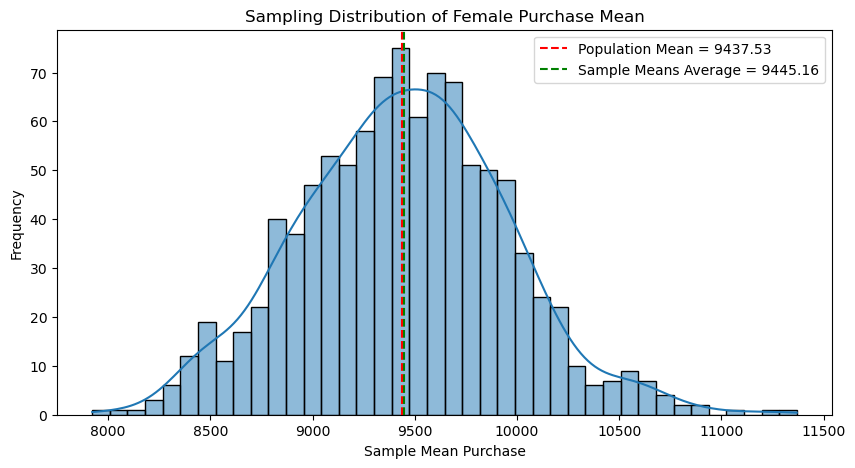

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_male,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_male:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of Female Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [ ]:
##Conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?

In [ ]:
##Confidence Intervals and Distribution of the Mean of the Expenses by Female and Male Customers 

##The Central Limit Theorem was used to generate sampling distributions of the mean purchase amount for both male and female customers 
##by repeatedly drawing random samples and calculating sample means.

## Key observations
## The sampling distribution of both male and female purchase were approximatlry normal.
##the average sample means was very close to the population means for both genders.
##A sample size increses the sample distribution became narrower and more concentrated around the population mean.
##Confidence interval width decresed with incresing sample size beacause the standard error decresed.
##When the confidence level increased from 90% to 95% and 99%, the confidence interval became wider because a higher confidence level requires a larger margin of error.



In [ ]:
##Are Confidence Intervals of Average Male and Female Spending Overlapping? How Can Walmart Leverage This Conclusion?

##The confidence intervals for male and female customers showed little or no overlap. This suggests that the average spending behavior of male and female customers is significantly different, 
##with male customers spending more per transaction.

##business implication for walmart 
##Walmart can design gender specific campaigns
##premium and high value products can be targeted more toward male customer since they 
#tend to spend more per purchase 
#walmart can create promotional offeres, bundles and discounts specifically aimed at female customer to increse basket size and average transaction value.

##Conclusion:

##The confidence interval analysis indicates that male customers spend significantly more per transaction than female customers. 
##Walmart can use this insight to improve targeted marketing strategies, increase customer engagement, and maximize revenue.


In [ ]:
##Perform the same activity for Married vs Unmarried and Age

In [7]:
df['Maritial_Label'] = df['Marital_Status'].map({0: 'Unmarried', 1:'Married'})
df


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Maritial_Label
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,Unmarried
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,Unmarried
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,Unmarried
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,Unmarried
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,Unmarried
...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368,Married
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371,Unmarried
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137,Married
550066,1006038,P00375436,F,55+,1,C,2,0,20,365,Unmarried


In [9]:
df.groupby('Maritial_Label')['Purchase'].mean()

Maritial_Label
Married      9261.174574
Unmarried    9265.907619
Name: Purchase, dtype: float64

In [10]:
amount = df.groupby('Maritial_Label')['Purchase'].count()
amount

Maritial_Label
Married      225337
Unmarried    324731
Name: Purchase, dtype: int64

In [8]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Maritial_Label'] == 'Married']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average Married Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average Married Spending: 9261.17
We are 95% confident that the true population average spending 
for all customers lies between 9240.46 and 9281.89


In [25]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Maritial_Label'] == 'Unmarried']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average Unmarried Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average Unmarried Spending: 9265.91
We are 95% confident that the true population average spending 
for all customers lies between 9248.62 and 9283.20


In [ ]:
##Yes, Married and unmarried almost spending same 

##Average purchage amount of male and female are alomost same. 
##Based on the analysis, the average spending per transaction for Marreid customers is approximately $9261.17, whereas for female customers it is approximately 9265.91


In [11]:
female_purchase = df[df['Maritial_Label']=='Married']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)

1000

In [27]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 9253.315968
sampling_std: 154.24818417953247


In [28]:
population_mean_female = df[df['Maritial_Label']=='Married']['Purchase'].mean()
population_mean_female

9261.174574082374

In [29]:
lower = sampling_mean - 1.96*sampling_std
lower

8950.989527008118

In [30]:
upper = sampling_mean + 1.96*sampling_std
upper

9555.642408991884

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


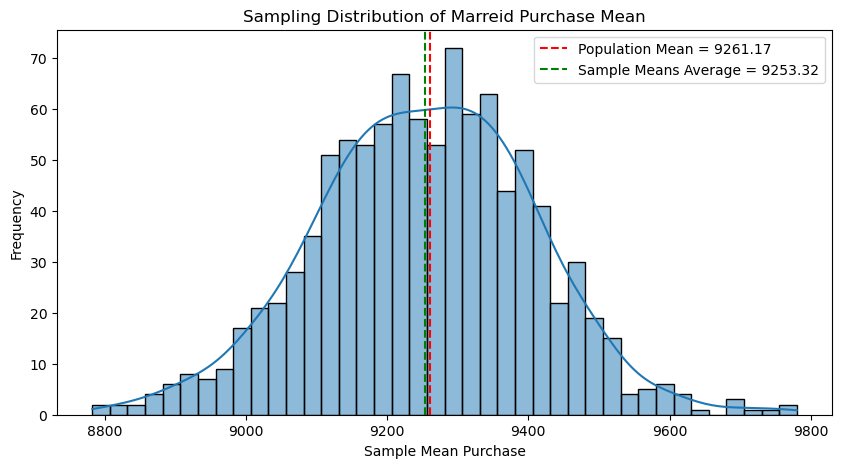

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of Marreid Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [50]:
female_purchase = df[df['Maritial_Label']=='Unmarried']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)

1000

In [39]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 9268.556555000001
sampling_std: 159.70746461548055


In [34]:
population_mean_female = df[df['Maritial_Label']=='Unmarried']['Purchase'].mean()
population_mean_female

9265.907618921507

In [35]:
lower = sampling_mean - 1.96*sampling_std
lower

8950.989527008118

In [36]:
upper = sampling_mean + 1.96*sampling_std
upper

9555.642408991884

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


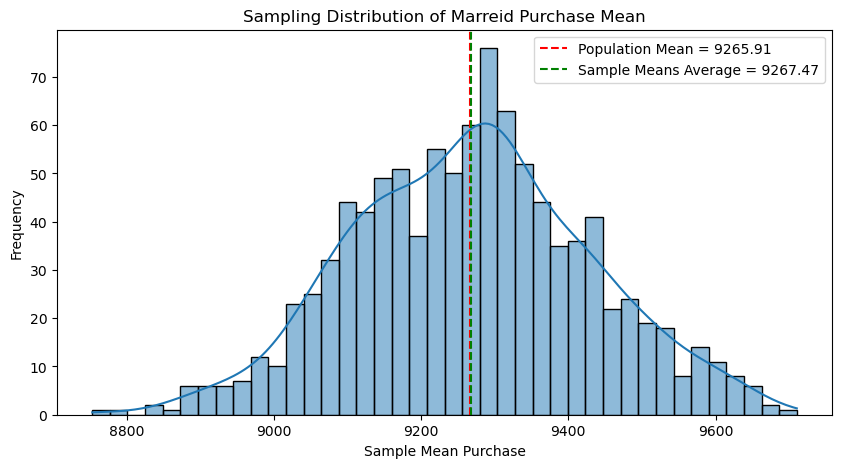

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of Marreid Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [ ]:
##Confidence Intervals and Distribution of the Mean of the Expenses by Marreid and unmarried Customers 

##The Central Limit Theorem was used to generate sampling distributions of the mean purchase amount for both male and female customers 
##by repeatedly drawing random samples and calculating sample means.

## Key observations
## The sampling distribution of both male and female purchase were approximatlry normal.
##the average sample means was very close to the population means for both genders.
##A sample size increses the sample distribution became narrower and more concentrated around the population mean.
##Confidence interval width decresed with incresing sample size beacause the standard error decresed.
##When the confidence level increased from 90% to 95% and 99%, the confidence interval became wider because a higher confidence level requires a larger margin of error.

In [ ]:
##here confidence intervals for male and female customers showed overlap. This suggests that the average spending behavior of married and unmarried customers is same.

In [12]:
age_map = {
    '0-17': '0-17',
    '18-25': '18-25',
    '26-35': '26-35',
    '36-45': '36-50',
    '46-50': '36-50',
    '51-55': '51+',
    '55+': '51+'
}

df['Age_Group'] = df['Age'].map(age_map)
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Maritial_Label,Age_Group
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,Unmarried,0-17
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,Unmarried,0-17
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,Unmarried,0-17
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,Unmarried,0-17
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,Unmarried,51+
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368,Married,51+
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371,Unmarried,26-35
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137,Married,26-35
550066,1006038,P00375436,F,55+,1,C,2,0,20,365,Unmarried,51+


In [13]:
df.groupby('Age_Group')['Purchase'].mean()

Age_Group
0-17     8933.464640
18-25    9169.663606
26-35    9252.690633
36-50    9295.331743
51+      9463.661678
Name: Purchase, dtype: float64

In [14]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Age_Group'] == '0-17']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average 0-17 Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average 0-17 Spending: 8933.46
We are 95% confident that the true population average spending 
for all customers lies between 8851.94 and 9014.99


In [15]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Age_Group'] == '18-25']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average 18-25  Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average 18-25  Spending: 9169.66
We are 95% confident that the true population average spending 
for all customers lies between 9138.41 and 9200.92


In [47]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Age_Group'] == '26-35']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average 26-35 Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average 26-35 Spending: 9252.69
We are 95% confident that the true population average spending 
for all customers lies between 9231.73 and 9273.65


In [48]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Age_Group'] == '36-50']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average 36-50 Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average 36-50 Spending: 9295.33
We are 95% confident that the true population average spending 
for all customers lies between 9270.46 and 9320.20


In [67]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

female_sample = df[df['Age_Group'] == '51+']['Purchase']

n = len(female_sample)
sample_mean = female_sample.mean()
sample_sem = stats.sem(female_sample)

confidence_level = 0.95
lower_bound, upper_bound = stats.t.interval(confidence = confidence_level, df = n-1, loc= sample_mean, scale = sample_sem)

print(f"Sample Average 55+ Spending: {sample_mean:.2f}")
print(f"We are 95% confident that the true population average spending ")
print(f"for all customers lies between {lower_bound:.2f} and {upper_bound:.2f}")

Sample Average 55+ Spending: 9463.66
We are 95% confident that the true population average spending 
for all customers lies between 9423.17 and 9504.16


In [ ]:

# conclusion 
## Age group having 51+ are more purchases.
## Age group haivng 0-17+ are having less purchases.

In [16]:
female_purchase = df[df['Age_Group']=='0-17']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)

1000

In [17]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 8934.243297
sampling_std: 162.65805401635293


In [18]:
population_mean_female = df[df['Age_Group']=='0-17']['Purchase'].mean()
population_mean_female

8933.464640444974

In [19]:
lower = sampling_mean - 1.96*sampling_std
lower

8615.433511127949

In [20]:
upper = sampling_mean + 1.96*sampling_std
upper

9253.053082872053

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


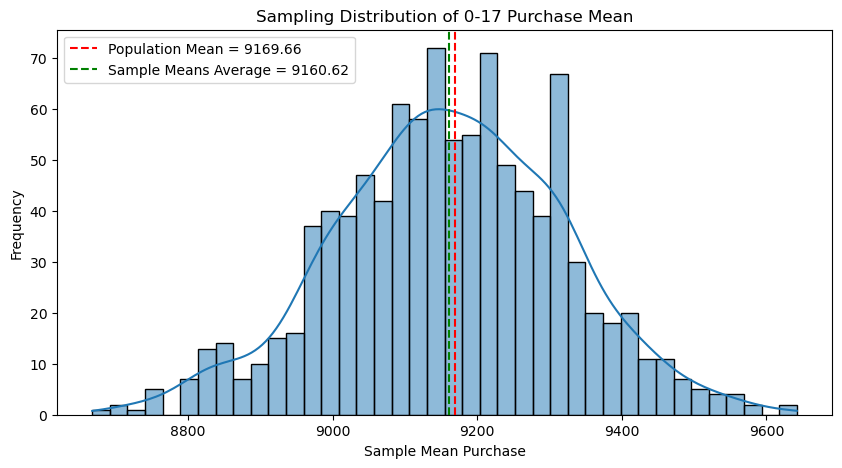

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of 0-17 Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [ ]:
### population average and sample avergae is almost same.

In [22]:
female_purchase = df[df['Age_Group']=='18-25']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)

1000

In [23]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 9160.623039
sampling_std: 158.1648434360098


In [24]:
population_mean_female = df[df['Age_Group']=='18-25']['Purchase'].mean()
population_mean_female

9169.663606261289

In [26]:
lower = sampling_mean - 1.96*sampling_std
lower

8850.619945865421

In [27]:
upper = sampling_mean + 1.96*sampling_std
upper

9470.62613213458

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


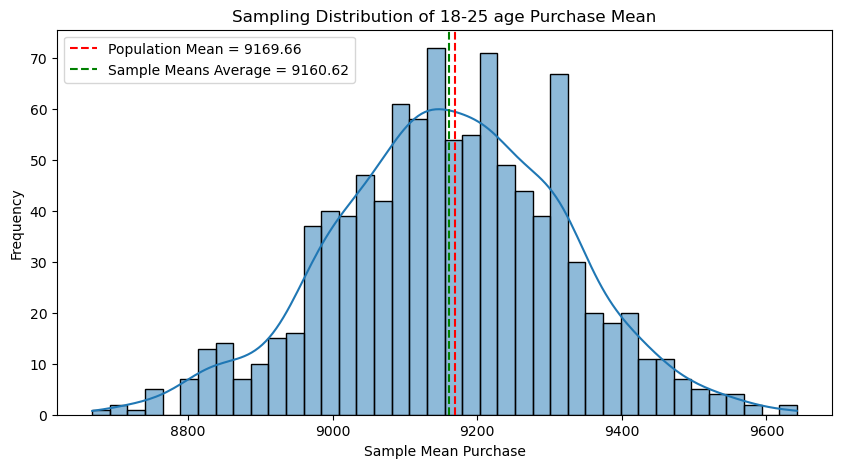

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of 18-25 age Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [34]:
female_purchase = df[df['Age_Group']=='36-50']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)

1000

In [35]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 9293.061776
sampling_std: 165.78164806647874


In [36]:
population_mean_female = df[df['Age_Group']=='18-25']['Purchase'].mean()
population_mean_female

9169.663606261289

In [37]:
lower = sampling_mean - 1.96*sampling_std
lower

8968.129745789702

In [ ]:
upper = sampling_mean + 1.96*sampling_std
upper

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


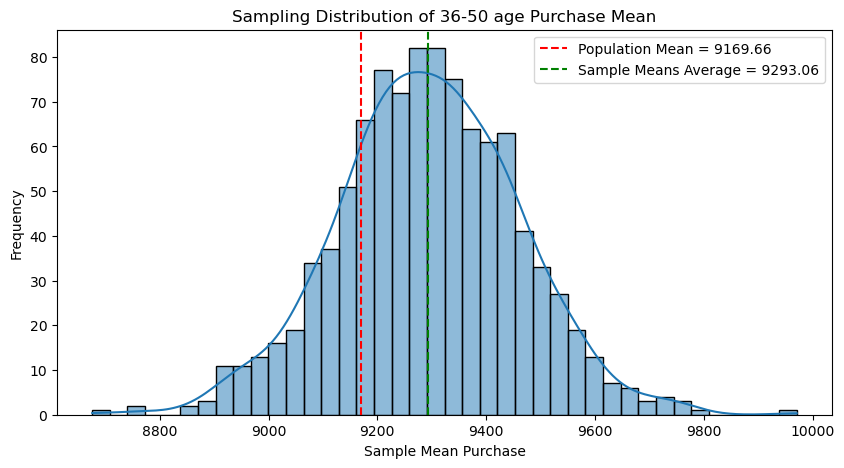

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of 36-50 age Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [44]:
female_purchase = df[df['Age_Group']=='51+']['Purchase']

sample_means = []

for i in range(1000):
    sample = female_purchase.sample(n=1000, replace= True)
    sample_means.append(sample.mean())

len(sample_means)

1000

In [45]:
import numpy as np

sampling_mean = np.mean(sample_means)
sampling_std = np.std(sample_means)
print(f'sampling_mean: {sampling_mean}')
print(f'sampling_std: {sampling_std}')

sampling_mean: 9469.871906999999
sampling_std: 168.14254705000263


In [46]:
population_mean_female = df[df['Age_Group']=='51+']['Purchase'].mean()
population_mean_female

9463.661678193484

In [47]:
lower = sampling_mean - 1.96*sampling_std
lower

9140.312514781994

In [48]:
upper = sampling_mean + 1.96*sampling_std
upper

9799.431299218004

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


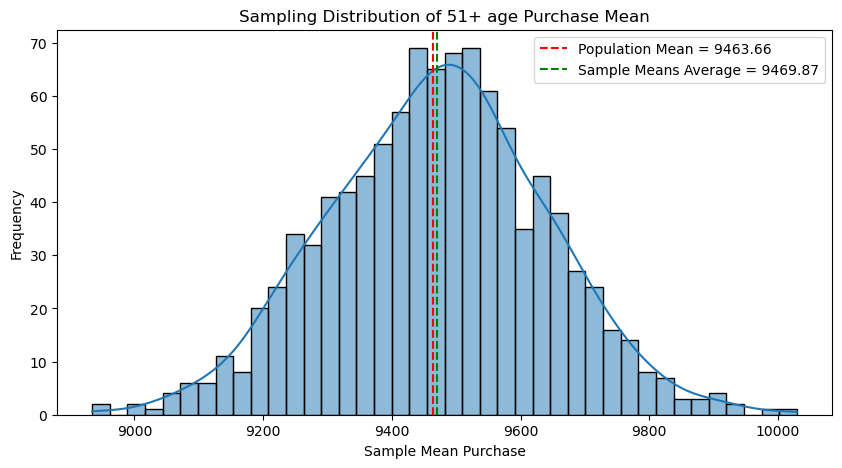

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(sample_means, bins= 40, kde=True)

plt.axvline(population_mean_female,
            color='red',
            linestyle='--',
            label=f'Population Mean = {population_mean_female:.2f}')

plt.axvline(np.mean(sample_means),
            color='green',
            linestyle='--',
            label=f'Sample Means Average = {np.mean(sample_means):.2f}')

plt.title('Sampling Distribution of 51+ age Purchase Mean')
plt.xlabel('Sample Mean Purchase')
plt.ylabel('Frequency')
plt.legend()

plt.show()

#3Give recommendations and action items to Walmart.

##Gender-Based Recommendation

# Recommendation
# Target male customers with premium and high-value products.
# Create personalized offers for female customers to increase basket size.
# Use gender-specific product recommendations during sales events.
# Design marketing campaigns differently for male and female shoppers.

# Marital Status Recommendation

# Marital status should not be the primary basis for customer segmentation.
# Focus marketing efforts on other variables such as age and gender.

# Age Group Recommendation

# Findings
# Spending increases with age.
# Customers aged 51+ have the highest average purchase amount.
# Customers aged 0-17 have the lowest spending.

# Business Impact

# Age-based segmentation appears more effective than marital-status-based segmentation because spending increases consistently with age.

# Overall Walmart Recommendation

# Key Insights
# Male customers spend more than female customers.
# Spending generally increases with age.
# Customers aged 51+ are the highest-spending segment.
# Marital status may have limited influence compared to age and gender.
# Confidence interval analysis confirms that the observed spending differences are statistically reliable.

# Final Recommendation

# Walmart should prioritize age- and gender-based customer segmentation. The company should focus premium product marketing on male customers 
# and older age groups (36+ years, especially 51+ years), while using targeted discounts and engagement strategies to increase spending among younger customers and female shoppers. 
# This data-driven segmentation can improve marketing efficiency, customer retention, and overall revenue generation.